# Compare pool metrics
Load all metrics parquets from `artifacts/` and compare MAE, RMSE, MAPE across models (baseline, lstm, xgboost, lightgbm, ridge, xgb_lstm_stack, stack_simple_avg, stack_ridge_meta, chronos).

In [5]:
from pathlib import Path
import pandas as pd

ARTIFACTS_DIR = Path.cwd() / "artifacts"

files = {
    "baseline": "metrics_baseline_pool.parquet",
    "lstm": "metrics_lstm_pool.parquet",
    "xgboost": "metrics_xgboost_pool.parquet",
    "lightgbm": "metrics_lightgbm_pool.parquet",
    "ridge": "metrics_elasticnet_pool.parquet",
    "xgb_lstm_stack": "metrics_xgb_lstm_stack_pool.parquet",
    "stack_simple_avg": "metrics_stack_simple_avg_pool.parquet",
    "stack_ridge_meta": "metrics_stack_ridge_meta_pool.parquet",
    "chronos": "metrics_chronos_pool.parquet",
}
dfs = []
for name, f in files.items():
    p = ARTIFACTS_DIR / f
    if p.exists():
        df = pd.read_parquet(p).copy()
        df["model"] = name
        dfs.append(df)
    else:
        print(f"Missing: {p}")

if not dfs:
    raise SystemExit("No metrics files found. Run 01–04 pool notebooks first.")
all_metrics = pd.concat(dfs, ignore_index=True)
print("Overall :")
overall = all_metrics[all_metrics["symbol"] == "overall"].sort_values('MAE')
overall

Overall :


,model,symbol,MAE,RMSE,MAPE_%
98,chronos,overall,11.202640,15.065149,4.350216
87,stack_ridge_meta,overall,11.367022,15.528722,4.357967
54,ridge,overall,11.412063,15.759329,4.365144
10,baseline,overall,11.423985,15.081298,4.476126
65,xgb_lstm_stack,overall,11.439762,15.763910,4.320761
76,stack_simple_avg,overall,11.542073,15.766531,4.401198
43,lightgbm,overall,11.544340,15.978432,4.327481
32,xgboost,overall,11.574360,15.995017,4.332354
21,lstm,overall,11.592697,15.541788,4.436494


In [6]:
all_metrics

,model,symbol,MAE,RMSE,MAPE_%
0,baseline,AAPL,10.614806,12.612144,4.019096
1,baseline,MSFT,21.562252,25.439666,5.062936
2,baseline,GOOGL,13.646728,15.443446,4.253209
3,baseline,AMZN,13.401750,15.751148,6.099282
4,baseline,JPM,13.725844,15.328880,4.346785
...,...,...,...,...,...
94,chronos,WMT,4.897155,5.577521,3.994677
95,chronos,SPY,5.933265,7.075163,0.863815
96,chronos,XOM,7.773772,9.161092,5.578577
97,chronos,NVDA,6.244659,7.320721,3.397057


In [7]:
# Pivot: rows = symbol (or overall), columns = model, values = MAE / RMSE / MAPE_%
for metric in ["MAE", "RMSE", "MAPE_%"]:
    if metric not in all_metrics.columns:
        continue
    pt = all_metrics.pivot_table(index="symbol", columns="model", values=metric)
    print(f"\n--- {metric} ---")
    print(pt.to_string())
    print()


--- MAE ---
model     baseline    chronos   lightgbm       lstm      ridge  stack_ridge_meta  stack_simple_avg  xgb_lstm_stack    xgboost
symbol                                                                                                                       
AAPL     10.614806  11.147629  11.188913  11.609806  10.788102         10.968084         11.035076       10.962351  11.348726
AMZN     13.401750  13.398862  13.636857  13.262930  13.327648         13.352919         14.155798       13.569823  13.492372
GOOGL    13.646728  13.029338  13.208618  13.245999  13.426785         13.075452         13.760082       13.346342  13.138760
JNJ      13.146178  12.451304  10.532497  12.012337  11.689273         11.460942         11.089767       10.710588  10.520188
JPM      13.725844  12.703494  13.795545  13.808767  13.406035         13.677636         13.465054       13.663833  13.844364
MSFT     21.562252  24.446923  28.095241  24.586888  27.614160         26.344747         26.575434       

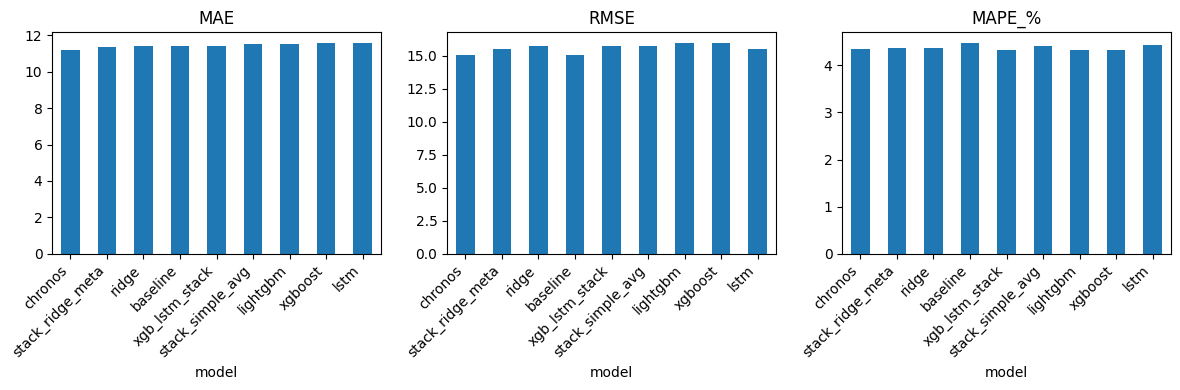

In [8]:
# Overall row only: bar comparison

if overall.empty:
    overall = all_metrics.groupby("model").agg({"MAE": "mean", "RMSE": "mean", "MAPE_%": "mean"}).reset_index()

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["MAE", "RMSE", "MAPE_%"]):
    if col in overall.columns:
        overall.plot(x="model", y=col, kind="bar", ax=ax, legend=False)
        ax.set_title(col)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()